Mounted at /content/drive
Figures will be saved to: /content/drive/MyDrive/Bell_misture2
═════════════════════════════════════════════════════════════════
  JAX version  : 0.7.2
  Devices      : [CudaDevice(id=0)]
  Backend      : gpu
  64-bit check : float64
═════════════════════════════════════════════════════════════════
  SU(2) generators ready (3 params)  |  SU(4) generators ready (15 params)
  SU(3) generators ready (8 params)  |  SU(9) generators ready (80 params)
  SU(5) generators ready (24 params)  |  SU(25) generators ready (624 params)
  SU(7) generators ready (48 params)  |  SU(49) generators ready (2400 params)


═════════════════════════════════════════════════════════════════
  COMPUTING ANALYTICAL + NUMERICAL QUANTITIES
═════════════════════════════════════════════════════════════════

─────────────────────────────────────────────────────────────────
  d = 2  |  discord params = 3  |  cost params = 15  |  n_pts = 51
─────────────────────────────────────────────────────

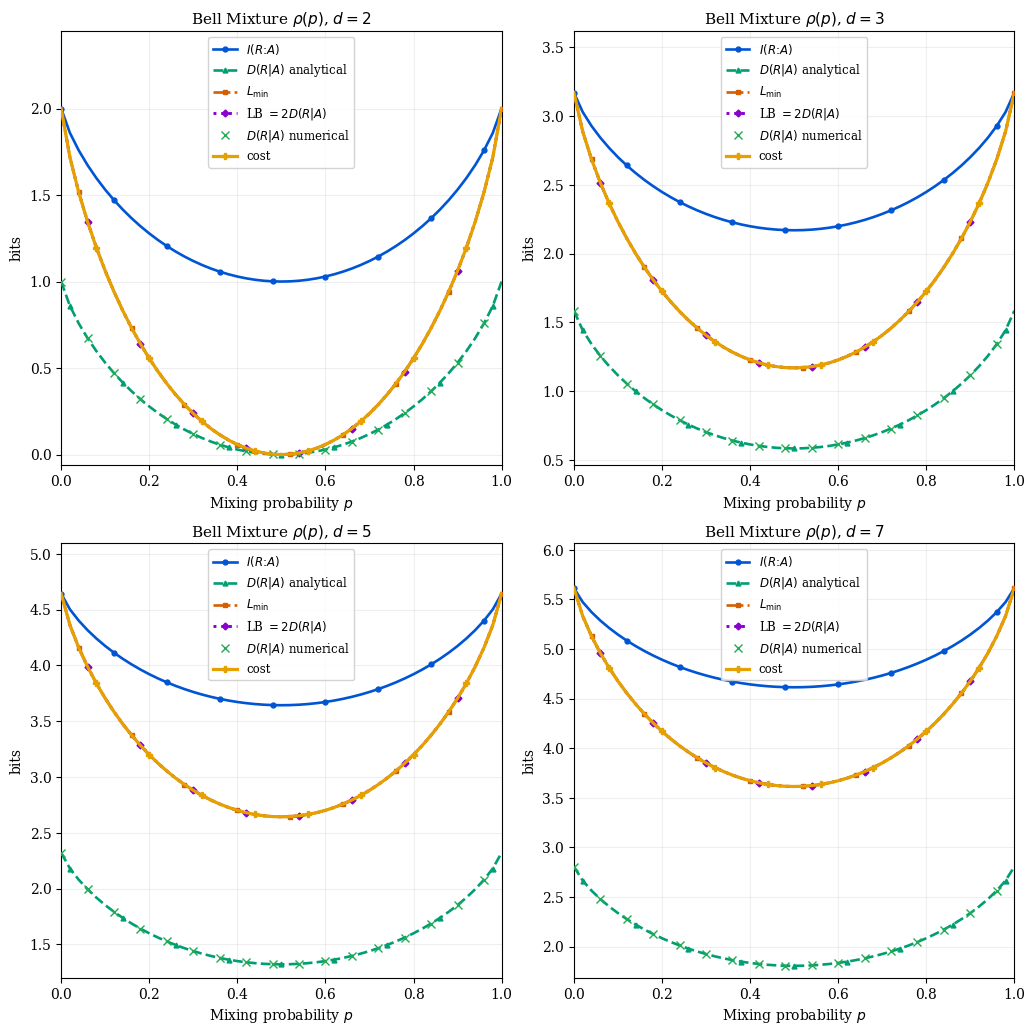

  Figure 1 saved.
  Generating Figure 2 ...


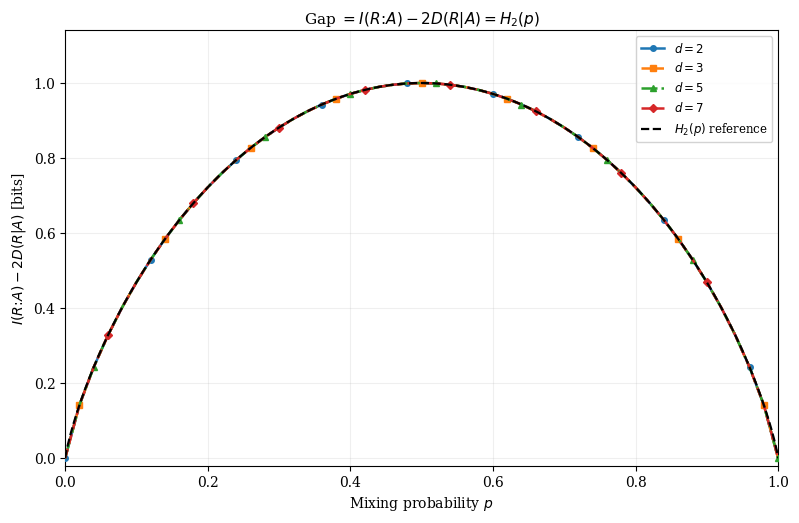

  Figure 2 saved.
  Generating Figure 3 ...


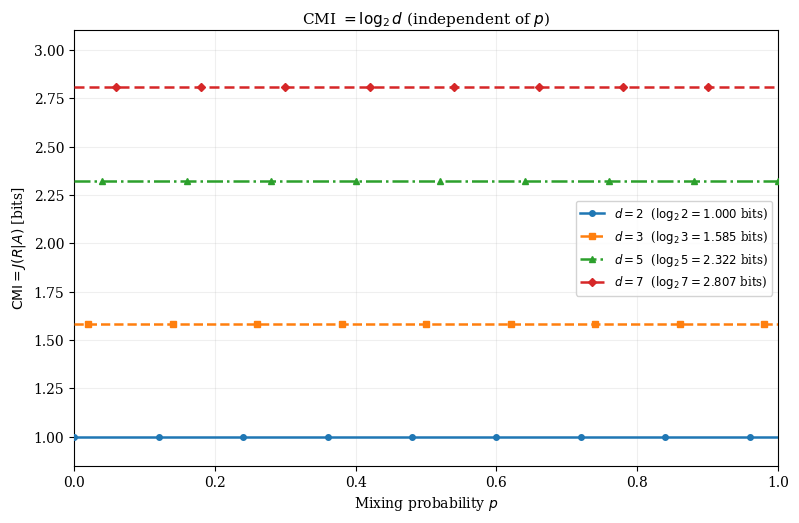

  Figure 3 saved.
  Generating Figure 4 ...


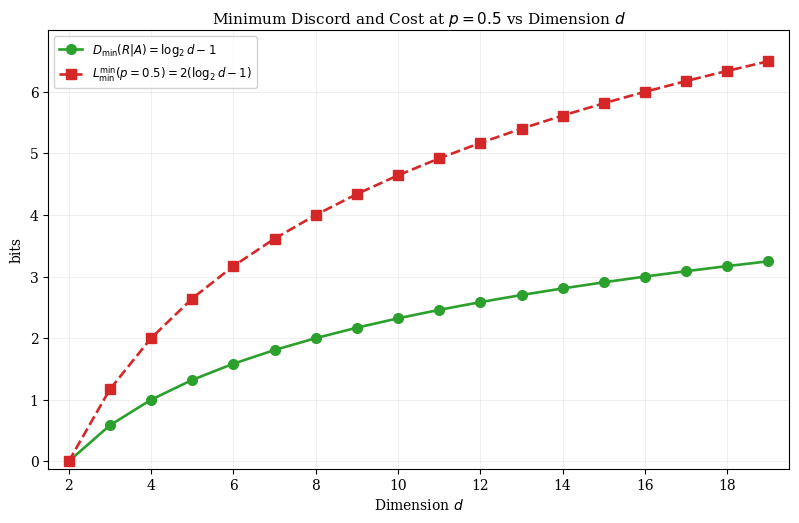

  Figure 4 saved.

════════════════════════════════════════════════════════════════════════════════
  TABLE 3 — Explicit numerical values for selected Bell mixture states
════════════════════════════════════════════════════════════════════════════════
  d      p    I(R:A)    D(R|A)        2D     Hb(p)     L_min        cost
────────────────────────────────────────────────────────────────────────────────
  2    0.0     2.000     1.000     2.000     0.000     2.000      2.0000
  2    0.5     1.000     0.000     0.000     1.000     0.000     -0.0000
  3    0.0     3.170     1.585     3.170     0.000     3.170      3.1699
  3    0.5     2.170     0.585     1.170     1.000     1.170      1.1699
  5    0.0     4.644     2.322     4.644     0.000     4.644      4.6439
  5    0.5     3.644     1.322     2.644     1.000     2.644      2.6439
  7    0.0     5.615     2.807     5.615     0.000     5.615      5.6147
  7    0.5     4.615     1.807     3.615     1.000     3.615      3.6147
══════════

In [ ]:
"""
bell_mixture_figures.py
═══════════════════════════════════════════════════════════════════════════════
Reproduces ALL figures from the Bell-mixture report.

Quantities computed
───────────────────
  • I(R:A)          – mutual information (analytical)
  • D(R|A)          – quantum discord (numerical, rank-1 projective measurement
                       optimisation via Adam + tight-Adam, fully on JAX/GPU)
  • L_min = 2D(R|A) – twice the discord (analytical from D)
  • LB              – lower bound = I(R:A) − |I(R:A) − 2D| (analytical)
  • cost            – min_U [I(R:B) + I(R:E)]  (numerical, U ∈ U(d²),
                       Cayley parametrisation, Adam Phase 1 + tight-Adam
                       Phase 2, fully on JAX/GPU)

FIGURES PRODUCED
────────────────
Figure 1 – 2×2 grid (d = 2, 3, 5, 7): I(R:A), D(R|A)_analytical, L_min,
           lower-bound, D(R|A) numerical (markers), AND cost (numerical)
Figure 2 – Gap = I(R:A) − 2D(R|A) = H_b(p), all dimensions
Figure 3 – CMI_min = log₂ d (horizontal lines), all dimensions
Figure 4 – D_min and L_min at p = 0.5 vs dimension d = 2 … 19

DISCORD METHOD
──────────────
Cayley map:  U = (I − iH)⁻¹(I + iH),  H = Σ θ_α G_α (Gell-Mann)
Phase 1 — Adam (warmup-cosine), vmap over restarts × all states.
Phase 2 — tight-Adam refinement (lr = 5e-4), best Phase-1 + fresh randoms.
Discord = max(0, I(R:A) − max_θ CMI(θ)).

COST METHOD
───────────
U ∈ U(d²) via Cayley map on Gell-Mann generators of SU(d²).
  ρ_RAE = ρ_RA ⊗ |0⟩⟨0|_E
  σ     = (I_R ⊗ U_{AE}) ρ_RAE (I_R ⊗ U†_{AE})
  cost  = I(R:B) + I(R:E)  computed from marginals of σ
Phase 1 — batched Adam over chunks of states, multiple restarts.
Phase 2 — tight-Adam refinement (lr = 1e-4), best Phase-1 + extra randoms.
Both phases run fully on JAX (GPU if available).

Runs on GPU if available; falls back to CPU automatically.
═══════════════════════════════════════════════════════════════════════════════
"""


from google.colab import drive
import os
drive.mount('/content/drive')
SAVE_DIR = '/content/drive/MyDrive/Bell_misture2'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Figures will be saved to: {SAVE_DIR}")

# ── Standard library ──────────────────────────────────────────────────────────
import time, gc, warnings
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
warnings.filterwarnings("ignore")

# ── JAX ───────────────────────────────────────────────────────────────────────
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax import jit, grad, vmap, lax
from functools import partial

# ── Optax ─────────────────────────────────────────────────────────────────────
import optax

# ─────────────────────────────────────────────────────────────────────────────
print("═" * 65)
print(f"  JAX version  : {jax.__version__}")
print(f"  Devices      : {jax.devices()}")
print(f"  Backend      : {jax.default_backend()}")
print(f"  64-bit check : {jnp.ones(1, dtype=jnp.float64).dtype}")
print("═" * 65)

# ═══════════════════════════════════════════════════════════════════════════════
#  GLOBAL CONFIGURATION
# ═══════════════════════════════════════════════════════════════════════════════

DIMS  = [2, 3, 5, 7]
N_PTS = {2: 51, 3: 51, 5: 51, 7: 51}

# Discord hyper-parameters (rank-1 projective measurement optimisation on A)
DISCORD_CFG = {
    2: {'n_adam_steps': 500, 'n_restarts': 40, 'lr': 0.05,
        'n_refine_steps': 400, 'n_refine_restarts': 4},
    3: {'n_adam_steps': 400, 'n_restarts': 30, 'lr': 0.04,
        'n_refine_steps': 300, 'n_refine_restarts': 4},
    5: {'n_adam_steps': 300, 'n_restarts': 20, 'lr': 0.03,
        'n_refine_steps': 200, 'n_refine_restarts': 3},
    7: {'n_adam_steps': 250, 'n_restarts': 15, 'lr': 0.02,
        'n_refine_steps': 150, 'n_refine_restarts': 2},
}

# Cost hyper-parameters  (adam_steps, lr, chunk_sz, n_adam_restarts,
#                          refine_steps, n_refine_restarts)
# The cost lives in U(d²) whose Gell-Mann parametrisation has d⁴−1 parameters.
COST_CFG = {
    2: (400, 0.030, 50, 5, 400, 4),
    3: (350, 0.025, 50, 3, 300, 3),
    5: (280, 0.020, 16, 2, 200, 2),
    7: (220, 0.015,  4, 2, 150, 1),
}

# ── Dimension-tuple caches ────────────────────────────────────────────────────
_DIMS_CACHE: dict = {}

def get_dims(d):
    if d not in _DIMS_CACHE:
        _DIMS_CACHE[d] = (d, d)
    return _DIMS_CACHE[d]

def get_dims3(d):
    key = (d, d, d)
    if key not in _DIMS_CACHE:
        _DIMS_CACHE[key] = key
    return _DIMS_CACHE[key]

# ── Matplotlib style ──────────────────────────────────────────────────────────
CM = 1 / 2.54

matplotlib.rcParams.update({
    'font.family'                   : 'serif',
    'font.size'                     : 10,
    'axes.titlesize'                : 11,
    'axes.labelsize'                : 10,
    'legend.fontsize'               : 8.5,
    'axes.spines.top'               : True,
    'axes.spines.right'             : True,
    'axes.grid'                     : True,
    'grid.alpha'                    : 0.20,
    'lines.linewidth'               : 1.8,
    'figure.constrained_layout.use' : True,
})

# ═══════════════════════════════════════════════════════════════════════════════
#  COLOUR / STYLE PALETTES
# ═══════════════════════════════════════════════════════════════════════════════

_DIM_STYLE = {
    2: dict(color='#1f77b4', ls='-',        lw=1.8, marker='o',
            ms=4, label=r'$d=2$'),
    3: dict(color='#ff7f0e', ls='--',       lw=1.8, marker='s',
            ms=4, label=r'$d=3$'),
    5: dict(color='#2ca02c', ls='-.',       lw=1.8, marker='^',
            ms=4, label=r'$d=5$'),
    7: dict(color='#d62728', ls=(0,(4,2)), lw=1.8, marker='D',
            ms=4, label=r'$d=7$'),
}

# ═══════════════════════════════════════════════════════════════════════════════
#  ANALYTICAL FORMULAS
# ═══════════════════════════════════════════════════════════════════════════════

def _xlg2(x):
    return float(x * np.log2(x)) if x > 1e-15 else 0.0

def binary_entropy(p):
    """H_b(p) = −p log₂ p − (1−p) log₂(1−p)"""
    if p <= 1e-15 or p >= 1 - 1e-15:
        return 0.0
    return -_xlg2(p) - _xlg2(1.0 - p)

def ana_I_RA(d, p):
    return max(0.0, 2.0 * np.log2(d) - binary_entropy(p))

def ana_discord(d, p):
    return max(0.0, np.log2(d) - binary_entropy(p))

def ana_Lmin(d, p):
    return 2.0 * ana_discord(d, p)

def ana_LB(d, p):
    I  = ana_I_RA(d, p)
    D2 = 2.0 * ana_discord(d, p)
    return I - abs(I - D2)

def ana_gap(d, p):
    return binary_entropy(p)

def ana_CMImin(d):
    return np.log2(d)

# ═══════════════════════════════════════════════════════════════════════════════
#  BELL MIXTURE STATE MATRIX
# ═══════════════════════════════════════════════════════════════════════════════

def bell_mixture_matrix_np(d, p):
    """
    ρ_RA(p) = p |Φ₁⟩⟨Φ₁| + (1−p) |Φ₂⟩⟨Φ₂|
    |Φ₁⟩ = (1/√d) Σ_i |i⟩|i⟩
    |Φ₂⟩ = (1/√d) Σ_i |i⟩|i+1 mod d⟩
    """
    dim  = d * d
    phi1 = np.zeros(dim, dtype=np.complex128)
    phi2 = np.zeros(dim, dtype=np.complex128)
    for i in range(d):
        phi1[i * d + i]            = 1.0 / np.sqrt(d)
        phi2[i * d + (i + 1) % d] = 1.0 / np.sqrt(d)
    return (p * np.outer(phi1, phi1.conj())
            + (1.0 - p) * np.outer(phi2, phi2.conj()))

# ═══════════════════════════════════════════════════════════════════════════════
#  GELL-MANN GENERATORS
# ═══════════════════════════════════════════════════════════════════════════════

_GM_CACHE: dict = {}

def gell_mann_np(n):
    """
    Returns the (n²−1) traceless Hermitian generators of SU(n) as an
    array of shape (n²−1, n, n) (standard Gell-Mann basis).
    """
    if n in _GM_CACHE:
        return _GM_CACHE[n]
    mats = []
    for j in range(n):
        for k in range(j + 1, n):
            L = np.zeros((n, n), dtype=np.complex128)
            L[j, k] = L[k, j] = 1.0
            mats.append(L)
    for j in range(n):
        for k in range(j + 1, n):
            L = np.zeros((n, n), dtype=np.complex128)
            L[j, k] = -1j;  L[k, j] = 1j
            mats.append(L)
    for l in range(1, n):
        L = np.zeros((n, n), dtype=np.complex128)
        c = np.sqrt(2.0 / (l * (l + 1)))
        for j in range(l):
            L[j, j] = c
        L[l, l] = -l * c
        mats.append(L)
    G = np.stack(mats).astype(np.complex128)
    _GM_CACHE[n] = G
    return G

# Pre-build generators for all required dimensions (both d and d²)
for _d in DIMS:
    gell_mann_np(_d)           # for discord  (U(d)  parametrisation)
    gell_mann_np(_d * _d)      # for cost     (U(d²) parametrisation)
    print(f"  SU({_d}) generators ready ({_d**2-1} params)  |  "
          f"SU({_d**2}) generators ready ({_d**4-1} params)")
print()

# ═══════════════════════════════════════════════════════════════════════════════
#  JAX QUANTUM PRIMITIVES
# ═══════════════════════════════════════════════════════════════════════════════

@partial(jit, static_argnums=(1, 2))
def partial_trace_jax(rho, keep, dims):
    """Partial trace keeping subsystems listed in `keep`."""
    n     = len(dims)
    rho_t = rho.reshape(list(dims) + list(dims))
    for ax in sorted([i for i in range(n) if i not in keep], reverse=True):
        cur_n = rho_t.ndim // 2
        rho_t = jnp.trace(rho_t, axis1=ax, axis2=ax + cur_n)
    d_keep = int(np.prod([dims[i] for i in sorted(keep)]))
    return rho_t.reshape(d_keep, d_keep)

@jit
def entropy_jax(rho):
    """Von Neumann entropy S(ρ) in bits, numerically stable."""
    ev    = jnp.linalg.eigvalsh(rho).real
    ev    = jnp.clip(ev, 0.0)
    total = ev.sum()
    ev    = jnp.where(total > 1e-30, ev / total, ev)
    safe  = jnp.where(ev > 1e-15, ev, jnp.ones_like(ev))
    return -jnp.sum(jnp.where(ev > 1e-15, ev * jnp.log2(safe), 0.0))

@jit
def mutual_info_jax(rho_AB, rho_A, rho_B):
    return entropy_jax(rho_A) + entropy_jax(rho_B) - entropy_jax(rho_AB)

# ═══════════════════════════════════════════════════════════════════════════════
#  DISCORD — CAYLEY U(d) PARAMETRISATION
#
#  H = Σ_α θ_α G_α   (Gell-Mann, d²−1 generators)
#  U = (I + iH)⁻¹ (I − iH)   [Cayley map → unitary on A]
#
#  CMI(θ) = S(R) − Σ_k p_k S(ρ_{R|k})
#  Discord = max(0, I(R:A) − max_θ CMI(θ))
# ═══════════════════════════════════════════════════════════════════════════════

def n_discord_params(d):
    return d * d - 1

@partial(jit, static_argnums=(2,))
def _cmi_cayley(params, rho_RA, d):
    """CMI for a rank-1 projective measurement on A, parametrised by Cayley."""
    dims   = (d, d)
    Id     = jnp.eye(d, dtype=jnp.complex128)
    G      = jnp.array(gell_mann_np(d))
    H      = jnp.einsum('k,kij->ij', params.astype(jnp.complex128), G)
    U_meas = jnp.linalg.solve((Id + 1j * H).T, (Id - 1j * H).T).T
    rho_t  = rho_RA.reshape(d, d, d, d)
    rho_R  = partial_trace_jax(rho_RA, (0,), dims)
    S_R    = entropy_jax(rho_R)

    def body(acc, k):
        v      = U_meas[:, k]
        tmp    = jnp.einsum('j,ijmn,n->im', v.conj(), rho_t, v)
        p_k    = jnp.real(jnp.trace(tmp))
        rho_Rk = jnp.where(p_k > 1e-12, tmp / (p_k + 1e-30),
                            jnp.zeros_like(rho_R))
        S_k    = jnp.where(p_k > 1e-12, entropy_jax(rho_Rk), 0.0)
        return acc + p_k * S_k, None

    cond, _ = lax.scan(body, 0.0, jnp.arange(d))
    return S_R - cond

@partial(jit, static_argnums=(2,))
def _neg_cmi_cayley(params, rho_RA, d):
    return -_cmi_cayley(params, rho_RA, d)

# ── Discord Phase 1: Adam (vmap over restarts × all states) ──────────────────

def _make_discord_adam(lr, n_steps):
    schedule = optax.warmup_cosine_decay_schedule(
        init_value   = lr * 0.1,
        peak_value   = lr,
        warmup_steps = max(20, n_steps // 10),
        decay_steps  = n_steps,
        end_value    = lr * 0.005,
    )
    return optax.chain(optax.clip_by_global_norm(0.5), optax.adam(schedule))

@partial(jit, static_argnums=(2,))
def _discord_adam_all_states(init_params_all, rho_batch, d):
    """
    init_params_all : (n_states, n_restarts, n_d_params)
    rho_batch       : (n_states, d², d²)
    Returns: best_cmis (n_states,), best_params (n_states, n_d_params)
    """
    cfg       = DISCORD_CFG[d]
    n_steps   = cfg['n_adam_steps']
    lr        = cfg['lr']
    optimizer = _make_discord_adam(lr, n_steps)
    grad_fn   = grad(_neg_cmi_cayley)

    def run_one_restart(params_init, rho):
        opt_st = optimizer.init(params_init)
        def body(carry, _):
            p, o       = carry
            g          = grad_fn(p, rho, d)
            upd, new_o = optimizer.update(g, o)
            return (optax.apply_updates(p, upd), new_o), None
        (p_final, _), _ = lax.scan(body, (params_init, opt_st),
                                   None, length=n_steps)
        return _cmi_cayley(p_final, rho, d), p_final

    def one_state(restarts_batch, rho):
        cmis, params_final = vmap(lambda p: run_one_restart(p, rho))(restarts_batch)
        best_idx = jnp.argmax(cmis)
        return cmis[best_idx], params_final[best_idx]

    return vmap(one_state)(init_params_all, rho_batch)

# ── Discord Phase 2: Tight-Adam refinement ───────────────────────────────────

@partial(jit, static_argnums=(2,))
def _discord_refine_all_states(all_inits, rho_batch, d):
    """
    all_inits : (n_states, n_refine_restarts+1, n_d_params)
    rho_batch : (n_states, d², d²)
    Returns: best_params (n_states, n_d_params)
    """
    cfg            = DISCORD_CFG[d]
    n_refine_steps = cfg['n_refine_steps']
    optimizer      = _make_discord_adam(5e-4, n_refine_steps)
    grad_fn        = grad(_neg_cmi_cayley)

    def refine_one(params_init, rho):
        opt_st = optimizer.init(params_init)
        def body(carry, _):
            p, o       = carry
            g          = grad_fn(p, rho, d)
            upd, new_o = optimizer.update(g, o)
            return (optax.apply_updates(p, upd), new_o), None
        (p_final, _), _ = lax.scan(body, (params_init, opt_st),
                                   None, length=n_refine_steps)
        return _cmi_cayley(p_final, rho, d), p_final

    def one_state(inits_batch, rho):
        cmis, params_final = vmap(lambda p: refine_one(p, rho))(inits_batch)
        best_idx = jnp.argmax(cmis)
        return params_final[best_idx]

    return vmap(one_state)(all_inits, rho_batch)

# ── Discord: top-level driver ─────────────────────────────────────────────────

def quantum_discord_batch(rho_list, d):
    """Compute D(R|A) for every matrix in rho_list. Returns np.ndarray."""
    cfg        = DISCORD_CFG[d]
    n_restarts = cfg['n_restarts']
    n_r_extra  = cfg['n_refine_restarts']
    n_d_params = n_discord_params(d)
    scale      = np.pi / np.sqrt(d)
    dims       = get_dims(d)
    n_states   = len(rho_list)

    rho_batch = jnp.stack([jnp.array(rho) for rho in rho_list])

    def compute_I_RA(rho):
        rho_R = partial_trace_jax(rho, (0,), dims)
        rho_A = partial_trace_jax(rho, (1,), dims)
        return mutual_info_jax(rho, rho_R, rho_A)
    I_RA_all = np.array(vmap(compute_I_RA)(rho_batch))

    print(f"    [Discord d={d}] Compiling...", end=' ', flush=True)
    t_c = time.time()
    key = jax.random.PRNGKey(42)
    key, sk = jax.random.split(key)
    dummy1 = jax.random.uniform(sk, (1, n_restarts, n_d_params),
                                minval=-scale, maxval=scale, dtype=jnp.float64)
    _discord_adam_all_states(dummy1, rho_batch[:1], d)
    dummy2 = jax.random.uniform(sk, (1, n_r_extra + 1, n_d_params),
                                minval=-scale, maxval=scale, dtype=jnp.float64)
    _discord_refine_all_states(dummy2, rho_batch[:1], d)
    print(f"done ({time.time() - t_c:.0f}s)")

    print(f"    [Discord d={d}] Phase 1 — Adam "
          f"({n_restarts} restarts × {n_states} states)...", end=' ', flush=True)
    key, sk = jax.random.split(key)
    init_p1 = jax.random.uniform(sk, (n_states, n_restarts, n_d_params),
                                  minval=-scale, maxval=scale, dtype=jnp.float64)
    t0 = time.time()
    best_cmis_jnp, best_params_jnp = _discord_adam_all_states(init_p1, rho_batch, d)
    best_cmis = np.array(best_cmis_jnp)
    print(f"done ({time.time()-t0:.0f}s)  CMI: [{best_cmis.min():.4f}, {best_cmis.max():.4f}]")

    print(f"    [Discord d={d}] Phase 2 — Refinement "
          f"({n_r_extra+1} inits × {n_states} states)...", end=' ', flush=True)
    key, sk = jax.random.split(key)
    rand_p2 = jax.random.uniform(sk, (n_states, n_r_extra, n_d_params),
                                  minval=-scale, maxval=scale, dtype=jnp.float64)
    all_p2 = jnp.concatenate([best_params_jnp[:, None, :], rand_p2], axis=1)
    t0 = time.time()
    final_params    = _discord_refine_all_states(all_p2, rho_batch, d)
    final_cmis      = np.array(
        vmap(lambda p, rho: _cmi_cayley(p, rho, d))(final_params, rho_batch))
    best_cmis_final = np.maximum(best_cmis, final_cmis)
    print(f"done ({time.time()-t0:.0f}s)  CMI: [{best_cmis_final.min():.4f}, {best_cmis_final.max():.4f}]")

    discord_arr = np.maximum(0.0, I_RA_all - best_cmis_final)
    print(f"    [Discord d={d}] D(R|A): [{discord_arr.min():.4f}, {discord_arr.max():.4f}]")

    del rho_batch, init_p1, all_p2, best_params_jnp, final_params
    gc.collect()
    return discord_arr

# ═══════════════════════════════════════════════════════════════════════════════
#  COST FUNCTION  min_U [ I(R:B) + I(R:E) ]
#
#  Environment isometry: the ancilla E starts in |0⟩ and the gate U ∈ U(d²)
#  acts on A⊗E jointly (we keep R as a spectator).
#
#  ρ_RAE = ρ_RA ⊗ |0⟩⟨0|_E          (d³ × d³ matrix)
#  σ     = (I_R ⊗ U_{AE}) ρ_RAE (I_R ⊗ U†_{AE})
#  cost  = I(R:B) + I(R:E)
#
#  U ∈ U(d²) via Cayley map on Gell-Mann generators of SU(d²):
#    H = Σ_α θ_α G_α   (d⁴−1 real parameters)
#    U = (I + iH + ε I)⁻¹ (I − iH)   [regularised Cayley map]
# ═══════════════════════════════════════════════════════════════════════════════

def n_cost_params(d):
    """Number of real parameters for U ∈ U(d²): d⁴ − 1."""
    return d ** 4 - 1

@partial(jit, static_argnums=(1,))
def _build_u_cayley_cost(params, d):
    """Build U ∈ U(d²) from real parameter vector via regularised Cayley map."""
    n  = d * d
    G  = jnp.array(gell_mann_np(n))
    H  = jnp.einsum('k,kij->ij', params.astype(jnp.complex128), G)
    I  = jnp.eye(n, dtype=jnp.complex128)
    return jnp.linalg.solve((I + 1j * H + 1e-8 * I).T, (I - 1j * H).T).T

@partial(jit, static_argnums=(2,))
def _cost_from_params(params, rho_RA, d):
    """
    Compute I(R:B) + I(R:E) for the isometric extension defined by U.
    System ordering in σ: R ⊗ B ⊗ E  (B = output of A channel).
    dims3 = (d, d, d).
    """
    U       = _build_u_cayley_cost(params, d)
    ket0    = jnp.zeros(d, dtype=jnp.complex128).at[0].set(1.0)
    rho_E0  = jnp.outer(ket0, ket0)
    I_R     = jnp.eye(d, dtype=jnp.complex128)
    rho_RAE = jnp.kron(rho_RA, rho_E0)           # d³ × d³
    U_full  = jnp.kron(I_R, U)                    # d³ × d³
    sigma   = U_full @ rho_RAE @ U_full.conj().T
    dims3   = get_dims3(d)
    sig_R   = partial_trace_jax(sigma, (0,),      dims3)
    sig_B   = partial_trace_jax(sigma, (1,),      dims3)
    sig_E   = partial_trace_jax(sigma, (2,),      dims3)
    sig_RB  = partial_trace_jax(sigma, (0, 1),    dims3)
    sig_RE  = partial_trace_jax(sigma, (0, 2),    dims3)
    I_RB    = entropy_jax(sig_R) + entropy_jax(sig_B) - entropy_jax(sig_RB)
    I_RE    = entropy_jax(sig_R) + entropy_jax(sig_E) - entropy_jax(sig_RE)
    return (I_RB + I_RE).real

# ── Cost Phase 1: batched Adam ────────────────────────────────────────────────

def _make_cost_adam(lr, n_steps):
    schedule = optax.warmup_cosine_decay_schedule(
        init_value   = lr * 0.05,
        peak_value   = lr,
        warmup_steps = max(80, n_steps // 8),
        decay_steps  = n_steps,
        end_value    = lr * 0.01,
    )
    return optax.chain(optax.clip_by_global_norm(1.0), optax.adam(schedule))

@partial(jit, static_argnums=(2,))
def _cost_adam_batch(init_params_batch, rho_batch, d):
    """
    Run Adam simultaneously over a batch of (params, rho) pairs.
    init_params_batch : (chunk, n_cost_params)
    rho_batch         : (chunk, d², d²)
    Returns: final_costs (chunk,), final_params (chunk, n_cost_params)
    """
    cfg       = COST_CFG[d]
    n_steps   = cfg[0]
    lr        = cfg[1]
    optimizer = _make_cost_adam(lr, n_steps)
    grad_fn   = grad(_cost_from_params)

    def run_one(params_init, rho):
        opt_st = optimizer.init(params_init)
        def body(carry, _):
            p, o       = carry
            g          = grad_fn(p, rho, d)
            upd, new_o = optimizer.update(g, o)
            return (optax.apply_updates(p, upd), new_o), None
        (p_final, _), _ = lax.scan(body, (params_init, opt_st),
                                   None, length=n_steps)
        return _cost_from_params(p_final, rho, d), p_final

    return vmap(run_one)(init_params_batch, rho_batch)

# ── Cost Phase 2: tight-Adam refinement (batched) ────────────────────────────

@partial(jit, static_argnums=(2,))
def _cost_refine_batch(init_params_batch, rho_batch, d):
    """
    Tight-Adam refinement at lr=1e-4.
    init_params_batch : (chunk, n_cost_params)
    rho_batch         : (chunk, d², d²)
    Returns: final_costs (chunk,), final_params (chunk, n_cost_params)
    """
    n_steps   = COST_CFG[d][4]           # refine_steps
    optimizer = _make_cost_adam(1e-4, n_steps)
    grad_fn   = grad(_cost_from_params)

    def run_one(params_init, rho):
        opt_st = optimizer.init(params_init)
        def body(carry, _):
            p, o       = carry
            g          = grad_fn(p, rho, d)
            upd, new_o = optimizer.update(g, o)
            return (optax.apply_updates(p, upd), new_o), None
        (p_final, _), _ = lax.scan(body, (params_init, opt_st),
                                   None, length=n_steps)
        return _cost_from_params(p_final, rho, d), p_final

    return vmap(run_one)(init_params_batch, rho_batch)

# ── Cost: top-level driver ────────────────────────────────────────────────────

def optimize_cost_batch(rho_list, d, seed=42):
    """
    Minimise I(R:B) + I(R:E) over U ∈ U(d²) for each state in rho_list.

    Two phases, both fully on JAX/GPU:
      Phase 1 — batched Adam over chunks of states, n_adam_restarts passes.
      Phase 2 — tight-Adam refinement from Phase-1 best + extra random inits.

    Returns cost_arr : np.ndarray, shape (len(rho_list),)
    """
    n_adam_steps, lr, chunk_sz, n_adam_restarts, n_refine_steps, n_refine_restarts \
        = COST_CFG[d]
    n_params   = n_cost_params(d)
    scale      = np.pi / np.sqrt(d * d)
    n_states   = len(rho_list)
    rng        = np.random.default_rng(seed)

    def _rand_params(n):
        return rng.uniform(-scale, scale, (n, n_params)).astype(np.float64)

    rho_stack = [jnp.array(rho) for rho in rho_list]

    # ── JIT compilation warm-up ───────────────────────────────────────────────
    print(f"    [Cost d={d}] Compiling (n_params={n_params})...", end=' ', flush=True)
    t_c = time.time()
    _dummy_p  = jnp.array(_rand_params(min(chunk_sz, 2)))
    _dummy_rho = jnp.stack(rho_stack[:min(chunk_sz, 2)])
    # Pad if needed
    if len(rho_stack) < chunk_sz:
        pad_n = chunk_sz - len(rho_stack)
        _dummy_p   = jnp.concatenate([_dummy_p,
                                      jnp.zeros((pad_n, n_params), dtype=jnp.float64)])
        _dummy_rho = jnp.concatenate([_dummy_rho,
                                      jnp.zeros((pad_n,) + _dummy_rho.shape[1:],
                                                dtype=jnp.complex128)])
    _cost_adam_batch(_dummy_p[:chunk_sz], _dummy_rho[:chunk_sz], d)
    _cost_refine_batch(_dummy_p[:chunk_sz], _dummy_rho[:chunk_sz], d)
    print(f"done ({time.time()-t_c:.0f}s)")

    # ── Phase 1: Adam ─────────────────────────────────────────────────────────
    best_costs  = np.full(n_states, np.inf)
    best_params = _rand_params(n_states)    # placeholder

    chunk_indices = [list(range(i, min(i + chunk_sz, n_states)))
                     for i in range(0, n_states, chunk_sz)]

    print(f"    [Cost d={d}] Phase 1 — Adam "
          f"({n_adam_steps} steps × {n_adam_restarts} restarts, chunk={chunk_sz})")
    t0 = time.time()
    for restart in range(n_adam_restarts):
        print(f"      restart {restart+1}/{n_adam_restarts}", end=' ', flush=True)
        t_r = time.time()
        for idx in chunk_indices:
            nc      = len(idx)
            rho_c   = jnp.stack([rho_stack[i] for i in idx])
            params_c = jnp.array(_rand_params(nc))
            # Pad to chunk_sz for static shapes required by jit
            if nc < chunk_sz:
                pad_n   = chunk_sz - nc
                rho_c   = jnp.concatenate([rho_c,
                           jnp.zeros((pad_n,) + rho_c.shape[1:], dtype=jnp.complex128)])
                params_c = jnp.concatenate([params_c,
                           jnp.zeros((pad_n, n_params), dtype=jnp.float64)])
            costs_c, params_out = _cost_adam_batch(params_c, rho_c, d)
            costs_np  = np.array(costs_c[:nc])
            params_np = np.array(params_out[:nc])
            for k, gi in enumerate(idx):
                if costs_np[k] < best_costs[gi]:
                    best_costs[gi]  = costs_np[k]
                    best_params[gi] = params_np[k]
            del rho_c, params_c, costs_c, params_out
        gc.collect()
        print(f"→ mean={best_costs.mean():.5f}  min={best_costs.min():.6f}"
              f"  ({time.time()-t_r:.0f}s)")
    print(f"    [Cost d={d}] Adam done ({time.time()-t0:.0f}s)")

    # ── Phase 2: Tight-Adam refinement ───────────────────────────────────────
    print(f"    [Cost d={d}] Phase 2 — Tight-Adam refinement "
          f"({n_refine_steps} steps × {1+n_refine_restarts} inits per state)")
    t0 = time.time()
    for idx in chunk_indices:
        nc = len(idx)
        for init_source in range(1 + n_refine_restarts):
            rho_c = jnp.stack([rho_stack[i] for i in idx])
            if init_source == 0:
                # Use Phase-1 best
                params_c = jnp.array(np.stack([best_params[i] for i in idx]))
            else:
                params_c = jnp.array(_rand_params(nc))
            # Pad if needed
            if nc < chunk_sz:
                pad_n    = chunk_sz - nc
                rho_c    = jnp.concatenate([rho_c,
                            jnp.zeros((pad_n,) + rho_c.shape[1:], dtype=jnp.complex128)])
                params_c = jnp.concatenate([params_c,
                            jnp.zeros((pad_n, n_params), dtype=jnp.float64)])
            costs_c, params_out = _cost_refine_batch(params_c, rho_c, d)
            costs_np  = np.array(costs_c[:nc])
            params_np = np.array(params_out[:nc])
            for k, gi in enumerate(idx):
                if costs_np[k] < best_costs[gi]:
                    best_costs[gi]  = costs_np[k]
                    best_params[gi] = params_np[k]
            del rho_c, params_c, costs_c, params_out
        if (idx[-1] + 1) % max(1, n_states // 5) == 0 or idx[-1] == n_states - 1:
            print(f"      state {idx[-1]+1}/{n_states}  "
                  f"mean={best_costs[:idx[-1]+1].mean():.5f}  "
                  f"min={best_costs[:idx[-1]+1].min():.6f}")
        gc.collect()
    print(f"    [Cost d={d}] Refinement done ({time.time()-t0:.0f}s)  "
          f"cost: [{best_costs.min():.4f}, {best_costs.max():.4f}]")

    return best_costs

# ═══════════════════════════════════════════════════════════════════════════════
#  MAIN COMPUTATION LOOP
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "═" * 65)
print("  COMPUTING ANALYTICAL + NUMERICAL QUANTITIES")
print("═" * 65)

T_GLOBAL = time.time()

# data[d] = { 'p', 'I_RA', 'D_ana', 'Lmin', 'LB', 'gap', 'D_num', 'cost' }
data = {}

for d in DIMS:
    n_pts = N_PTS[d]
    P     = np.linspace(0.0, 1.0, n_pts)

    print(f"\n{'─'*65}")
    print(f"  d = {d}  |  discord params = {n_discord_params(d)}"
          f"  |  cost params = {n_cost_params(d)}  |  n_pts = {n_pts}")
    print(f"{'─'*65}")

    # Analytical curves
    I_RA  = np.array([ana_I_RA(d, p)    for p in P])
    D_ana = np.array([ana_discord(d, p) for p in P])
    Lmin  = np.array([ana_Lmin(d, p)    for p in P])
    LB    = np.array([ana_LB(d, p)      for p in P])
    gap   = np.array([ana_gap(d, p)     for p in P])

    rho_list = [bell_mixture_matrix_np(d, p) for p in P]

    # Numerical discord
    print(f"  [d={d}] Computing discord...")
    t0    = time.time()
    D_num = quantum_discord_batch(rho_list, d)
    print(f"  [d={d}] Discord done in {time.time()-t0:.0f}s")

    # Numerical cost
    print(f"  [d={d}] Optimising cost...")
    t0   = time.time()
    cost = optimize_cost_batch(rho_list, d, seed=42)
    print(f"  [d={d}] Cost done in {time.time()-t0:.0f}s")

    data[d] = {
        'p'    : P,
        'I_RA' : I_RA,
        'D_ana': D_ana,
        'Lmin' : Lmin,
        'LB'   : LB,
        'gap'  : gap,
        'D_num': D_num,
        'cost' : cost,
    }

    del rho_list
    gc.collect()

print(f"\n{'═'*65}")
print(f"  ALL DONE in {(time.time()-T_GLOBAL)/60:.1f} minutes")
print("═" * 65)

# ═══════════════════════════════════════════════════════════════════════════════
#  FIGURE 1 — 2×2 grid: I(R:A), D(R|A), L_min, LB, D_num, cost vs p
# ═══════════════════════════════════════════════════════════════════════════════

print("\n  Generating Figure 1 ...")

fig1, axes = plt.subplots(2, 2, figsize=(26 * CM, 26 * CM))

for ax, d in zip(axes.flat, DIMS):
    res = data[d]
    p   = res['p']
    n   = len(p)
    me  = max(1, n // 8)

    # I(R:A) — solid blue
    ax.plot(p, res['I_RA'],  color='#0055d4', ls='-',  lw=1.9,
            marker='o', ms=3.5, markevery=(0, me), zorder=4,
            label=r'$I(R\!:\!A)$')
    # D(R|A) analytical — dashed green
    ax.plot(p, res['D_ana'], color='#009E73', ls='--', lw=1.9,
            marker='^', ms=3.5, markevery=(1, me), zorder=4,
            label=r'$D(R|A)$ analytical')
    # L_min — dash-dot red
    ax.plot(p, res['Lmin'],  color='#D55E00', ls='-.', lw=1.9,
            marker='s', ms=3.5, markevery=(2, me), zorder=4,
            label=r'$L_{\min}$')
    # Lower bound — dotted purple
    ax.plot(p, res['LB'],    color='#8800cc', ls=':',  lw=2.1,
            marker='D', ms=3.5, markevery=(3, me), zorder=5,
            label=r'LB $= 2D(R|A)$')
    # D(R|A) numerical — cross markers
    step = max(1, n // 16)
    ax.plot(p[::step], res['D_num'][::step],
            color='#22aa55', marker='x', ms=6, lw=0, ls='none',
            zorder=6, label=r'$D(R|A)$ numerical')
    # Cost min_U[I(R:B)+I(R:E)] — thick orange solid
    ax.plot(p, res['cost'],  color='#e6a000', ls='-',  lw=2.3,
            marker='P', ms=4, markevery=(4, me), zorder=7,
            label=r'cost')

    ax.set_xlim(0.0, 1.0)
    all_vals = np.concatenate([res['I_RA'], res['D_ana'],
                               res['Lmin'], res['LB'], res['cost']])
    ax.set_ylim(bottom=max(-0.06, all_vals.min() - 0.12),
                top=all_vals.max() + 0.45)

    ax.set_xlabel(r'Mixing probability $p$')
    ax.set_ylabel('bits')
    ax.set_title(r'Bell Mixture $\rho(p)$, ' + f'$d = {d}$', pad=5)
    ax.legend(loc='best', framealpha=0.85, edgecolor='#cccccc')


fig1.savefig('figure1_bell_mixture_main.pdf', bbox_inches='tight')
fig1.savefig('figure1_bell_mixture_main.png', bbox_inches='tight', dpi=300)
plt.show()
print("  Figure 1 saved.")

# ═══════════════════════════════════════════════════════════════════════════════
#  FIGURE 2 — Gap = I(R:A) − 2D(R|A) = H_b(p)
# ═══════════════════════════════════════════════════════════════════════════════

print("  Generating Figure 2 ...")

fig2, ax2 = plt.subplots(figsize=(20 * CM, 13 * CM))
me_shift  = {2: 0, 3: 1, 5: 2, 7: 3}

for d in DIMS:
    res = data[d]
    p   = res['p']
    n   = len(p)
    sty = _DIM_STYLE[d]
    me  = max(1, n // 8)
    ax2.plot(p, res['gap'],
             color=sty['color'], ls=sty['ls'], lw=sty['lw'],
             marker=sty['marker'], ms=sty['ms'],
             markevery=(me_shift[d], me),
             label=sty['label'], zorder=4)

p_ref  = np.linspace(0, 1, 500)
Hb_ref = np.array([binary_entropy(pp) for pp in p_ref])
ax2.plot(p_ref, Hb_ref, 'k--', lw=1.6, label=r'$H_2(p)$ reference', zorder=5)

ax2.set_xlim(0.0, 1.0)
ax2.set_ylim(-0.02, 1.14)
ax2.set_xlabel(r'Mixing probability $p$')
ax2.set_ylabel(r'$I(R\!:\!A) - 2D(R|A)$ [bits]')
ax2.set_title(r'Gap $= I(R\!:\!A) - 2D(R|A) = H_2(p)$', pad=5)
ax2.legend(loc='best', framealpha=0.85, edgecolor='#cccccc')

fig2.savefig('figure2_gap.pdf', bbox_inches='tight')
fig2.savefig('figure2_gap.png', bbox_inches='tight', dpi=300)
plt.show()
print("  Figure 2 saved.")

# ═══════════════════════════════════════════════════════════════════════════════
#  FIGURE 3 — CMI_min = log₂ d (horizontal lines)
# ═══════════════════════════════════════════════════════════════════════════════

print("  Generating Figure 3 ...")

fig3, ax3 = plt.subplots(figsize=(20 * CM, 13 * CM))

for d in DIMS:
    res = data[d]
    p   = res['p']
    n   = len(p)
    sty = _DIM_STYLE[d]
    me  = max(1, n // 8)
    cmi_line = np.full(n, ana_CMImin(d))
    ax3.plot(p, cmi_line,
             color=sty['color'], ls=sty['ls'], lw=sty['lw'],
             marker=sty['marker'], ms=sty['ms'],
             markevery=(me_shift[d], me),
             label=sty['label'] + f'  ($\\log_2 {d} = {np.log2(d):.3f}$ bits)',
             zorder=4)

ax3.set_xlim(0.0, 1.0)
ax3.set_ylim(0.85, 3.10)
ax3.set_xlabel(r'Mixing probability $p$')
ax3.set_ylabel(r'$\mathrm{CMI} = J(R|A)$ [bits]')
ax3.set_title(r'CMI $= \log_2 d$ (independent of $p$)', pad=5)
ax3.legend(loc='best', framealpha=0.85, edgecolor='#cccccc')

fig3.savefig('figure3_CMImin.pdf', bbox_inches='tight')
fig3.savefig('figure3_CMImin.png', bbox_inches='tight', dpi=300)
plt.show()
print("  Figure 3 saved.")

# ═══════════════════════════════════════════════════════════════════════════════
#  FIGURE 4 — D_min and L_min at p = 0.5 vs dimension d = 2 … 19
# ═══════════════════════════════════════════════════════════════════════════════

print("  Generating Figure 4 ...")

dims_range = np.arange(2, 20)
Dmin_vals  = np.array([max(0.0, np.log2(d) - 1.0) for d in dims_range])
Lmin_vals  = 2.0 * Dmin_vals

fig4, ax4 = plt.subplots(figsize=(20 * CM, 13 * CM))

ax4.plot(dims_range, Dmin_vals,
         color='#2ca02c', marker='o', ms=7, lw=1.9, ls='-',
         label=r'$D_{\min}(R|A) = \log_2 d - 1$', zorder=4)
ax4.plot(dims_range, Lmin_vals,
         color='#d62728', marker='s', ms=7, lw=1.9, ls='--',
         label=r'$L^{\min}_{\min}(p=0.5) = 2(\log_2 d - 1)$', zorder=4)

ax4.set_xlim(dims_range[0] - 0.5, dims_range[-1] + 0.5)
ax4.set_ylim(-0.12, Lmin_vals.max() + 0.5)
ax4.xaxis.set_major_locator(ticker.MultipleLocator(2))
ax4.set_xlabel(r'Dimension $d$')
ax4.set_ylabel('bits')
ax4.set_title(r'Minimum Discord and Cost at $p = 0.5$ vs Dimension $d$', pad=5)
ax4.legend(loc='best', framealpha=0.85, edgecolor='#cccccc')

fig4.savefig('figure4_dim_scaling.pdf', bbox_inches='tight')
fig4.savefig('figure4_dim_scaling.png', bbox_inches='tight', dpi=300)
plt.show()
print("  Figure 4 saved.")

# ═══════════════════════════════════════════════════════════════════════════════
#  TABLE 3 — Numerical values for selected Bell mixture states
# ═══════════════════════════════════════════════════════════════════════════════

print()
print("═" * 80)
print("  TABLE 3 — Explicit numerical values for selected Bell mixture states")
print("═" * 80)
header = (f"{'d':>3}  {'p':>5}  {'I(R:A)':>8}  {'D(R|A)':>8}  {'2D':>8}"
          f"  {'Hb(p)':>8}  {'L_min':>8}  {'cost':>10}")
print(header)
print("─" * 80)

for d in DIMS:
    for p in (0.0, 0.5):
        I   = ana_I_RA(d, p)
        D   = ana_discord(d, p)
        L   = ana_Lmin(d, p)
        Hb  = binary_entropy(p)
        res = data[d]
        idx = int(np.argmin(np.abs(res['p'] - p)))
        c   = res['cost'][idx]
        print(f"{d:>3}  {p:>5.1f}  {I:>8.3f}  {D:>8.3f}  {2*D:>8.3f}"
              f"  {Hb:>8.3f}  {L:>8.3f}  {c:>10.4f}")

print("═" * 80)
print()

# ── Analytical vs numerical comparison at p = 0.5 ────────────────────────────
print("  Analytical vs Numerical Discord and Cost at p = 0.5")
print("─" * 60)
print(f"{'d':>3}  {'D_ana':>8}  {'D_num':>8}  {'|diff|':>8}  {'cost':>10}")
print("─" * 60)
for d in DIMS:
    D_a = ana_discord(d, 0.5)
    res = data[d]
    idx = int(np.argmin(np.abs(res['p'] - 0.5)))
    D_n = res['D_num'][idx]
    c   = res['cost'][idx]
    print(f"{d:>3}  {D_a:>8.4f}  {D_n:>8.4f}  {abs(D_a-D_n):>8.4f}  {c:>10.4f}")
print("─" * 60)
print()
print("  All figures saved to current directory.")
print("═" * 65)